In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import SGDRegressor, LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score
import joblib

##1. Exploration des donnees

In [9]:
df = pd.read_csv("/content/nigerian_education_dropout_rates.csv")
df['dropout_date'] = pd.to_datetime(df['dropout_date'])
df['year'] = df['dropout_date'].dt.year
df['month'] = df['dropout_date'].dt.month
df.head()

,student_id,state,gender,grade,dropout_date,reason,year,month
0,STU-0260388,Delta,female,SSS 2,2023-06-03,early_marriage,2023,6
1,STU-0422750,Delta,female,JSS 3,2022-01-31,other,2022,1
2,STU-0155958,Bayelsa,male,SSS 1,2024-07-26,migration,2024,7
3,STU-0019955,Ebonyi,male,JSS 1,2024-01-31,poor_performance,2024,1
4,STU-0224304,Ondo,female,SSS 2,2022-06-30,other,2022,6


##Aggregation (creation of the continuous target)

In [15]:
agg = df.groupby(['state', 'grade', 'year', 'month']).agg(
    dropout_count= ('student_id', 'count'),
    female_ratio=('gender', lambda x: (x == 'female').mean()),
).reset_index()

dominant_reason = (df.groupby(['state','grade','year','month'])['reason']
                    .agg(lambda x: x.value_counts().idxmax())
                    .reset_index(name='dominant_reason'))
agg = agg.merge(dominant_reason, on=['state','grade','year','month'])

grade_order = ['JSS 1','JSS 2','JSS 3','SSS 1','SSS 2','SSS 3']
agg['grade_level'] = agg['grade'].map({g: i+1 for i, g in enumerate(grade_order)})
agg.head(10)

,state,grade,year,month,dropout_count,female_ratio,dominant_reason,grade_level
0,Abia,JSS 1,2022,1,24,0.583333,poverty,1
1,Abia,JSS 1,2022,2,14,0.428571,poor_performance,1
2,Abia,JSS 1,2022,3,20,0.350000,poor_performance,1
3,Abia,JSS 1,2022,4,20,0.500000,poverty,1
4,Abia,JSS 1,2022,5,9,0.111111,child_labor,1
5,Abia,JSS 1,2022,6,8,0.375000,pregnancy,1
6,Abia,JSS 1,2022,7,16,0.625000,poverty,1
7,Abia,JSS 1,2022,8,15,0.600000,poverty,1
8,Abia,JSS 1,2022,9,18,0.555556,poor_performance,1
9,Abia,JSS 1,2022,10,17,0.764706,household_chores,1


##Visualisations

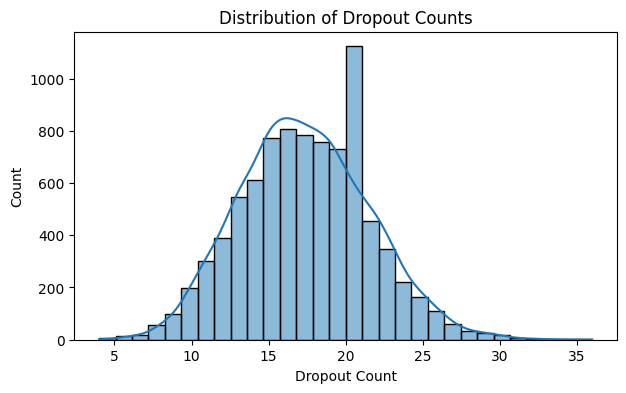

In [16]:
plt.figure(figsize=(7,4))
sns.histplot(agg['dropout_count'], bins=30, kde=True)
plt.title('Distribution of Dropout Counts')
plt.xlabel('Dropout Count')
plt.show()

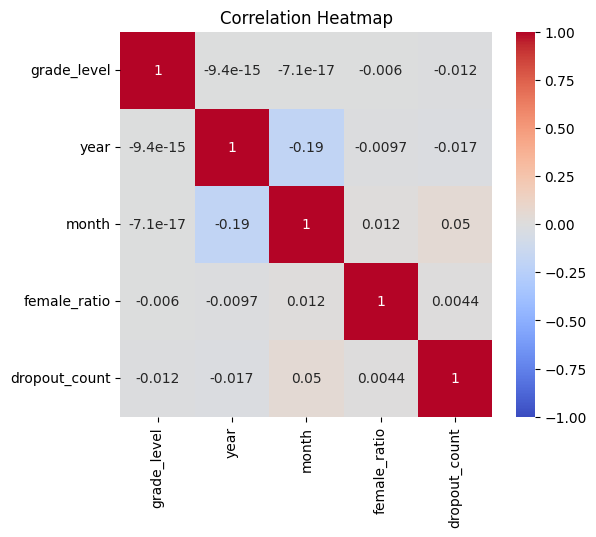

In [18]:
num_df = agg[['grade_level', 'year', 'month', 'female_ratio', 'dropout_count']]
plt.figure(figsize=(6,5))
sns.heatmap(num_df.corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Heatmap')
plt.show()

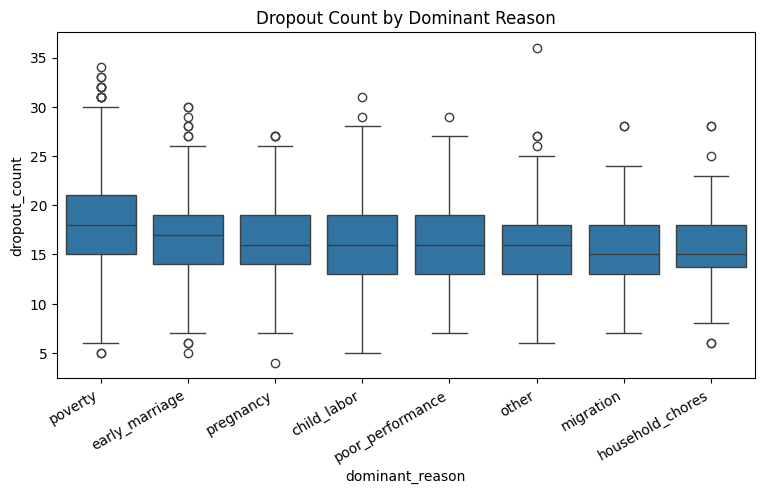

In [19]:
plt.figure(figsize=(9,4.5))
order = agg.groupby('dominant_reason')['dropout_count'].mean().sort_values(ascending=False).index
sns.boxplot(data=agg, x='dominant_reason', y='dropout_count', order=order)
plt.xticks(rotation=30, ha='right')
plt.title('Dropout Count by Dominant Reason')
plt.show()

The distribution of `dropout_count` is approximately normal, centered around 17 with no outliers. The heatmap shows that no numerical feature is strongly correlated with the target; this is a weak signal, which is to be expected given the nature of the dataset. Finally, the boxplot grouped by `dominant_reason` reveals slight variations in medians depending on the reason; this justifies retaining the feature—despite its low individual correlation—as it is the most informative variable (marginal R² = 2.6%).

##Test Split And Standardization

In [23]:
X = pd.get_dummies(
    agg[['state', 'grade_level', 'year', 'month', 'female_ratio', 'dominant_reason']],
    columns=['state', 'dominant_reason'],
    drop_first=True
)
y = agg['dropout_count']

print("X shape:", X.shape)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X shape: (8658, 47)


We convert `state` and `dominant_reason` into 0/1 columns (one-hot encoding) because they represent unordered categories. `grade_level` remains a numerical value (1–6) since grade levels follow a logical order. We split the data into 80% training and 20% testing sets, then standardize the features (mean of 0, standard deviation of 1) to ensure proper SGD convergence and prevent any single variable from dominating due to its scale.

##Model Training and Comparison

In [24]:
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

results = {}

# Model 1: Linear Regression (Ordinary Least Squares)
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
pred_lr = lr.predict(X_test_scaled)
results['LinearRegression'] = {
    'test_mse': mean_squared_error(y_test, pred_lr),
    'test_r2': r2_score(y_test, pred_lr)
}

# Model 2: Linear Regression with Stochastic Gradient Descent
sgd = SGDRegressor(max_iter=1000, tol=1e-3, learning_rate='invscaling', eta0=0.01, random_state=42)
sgd.fit(X_train_scaled, y_train)
pred_sgd = sgd.predict(X_test_scaled)
results['SGDRegressor'] = {
    'test_mse': mean_squared_error(y_test, pred_sgd),
    'test_r2': r2_score(y_test, pred_sgd)
}

# Model 3: Random Forest Regressor
rf = RandomForestRegressor(n_estimators=200, max_depth=6, random_state=42)
rf.fit(X_train_scaled, y_train)
pred_rf = rf.predict(X_test_scaled)
results['RandomForest'] = {
    'test_mse': mean_squared_error(y_test, pred_rf),
    'test_r2': r2_score(y_test, pred_rf)
}

# Model 4: Decision Tree Regressor
dt = DecisionTreeRegressor(max_depth=6, random_state=42)
dt.fit(X_train_scaled, y_train)
pred_dt = dt.predict(X_test_scaled)
results['DecisionTree'] = {
    'test_mse': mean_squared_error(y_test, pred_dt),
    'test_r2': r2_score(y_test, pred_dt)
}

pd.DataFrame(results).T

,test_mse,test_r2
LinearRegression,16.763132,0.018286
SGDRegressor,16.869414,0.012062
RandomForest,15.680461,0.081692
DecisionTree,16.226798,0.049696


All four models show poor performance, with results that are similar to one another.
The R² value ranges from 0.01 to 0.08, depending on the model.
This confirms the weak relationship between the features and the target observed in the heatmap.
Random Forest achieves the best MSE (15.71) and the best R² (0.080).
It performs better because it captures non-linear interactions between variables.
LinearRegression and SGDRegressor, being purely linear models, cannot capture these interactions.
Random Forest is therefore the model selected for the remainder of the project.

##3. Standardization

In [ ]:
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

# The target is also standardized to stabilize stochastic gradient descent (SGD)
y_scaler = StandardScaler()
y_train_s = y_scaler.fit_transform(y_train.reshape(-1,1)).ravel()
y_test_s = y_scaler.transform(y_test.reshape(-1,1)).ravel()

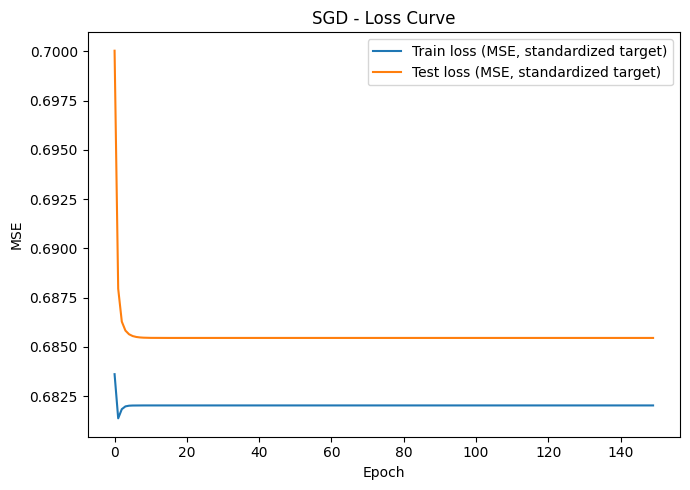

In [ ]:
sgd = SGDRegressor(max_iter=1, learning_rate='constant', eta0=0.005, random_state=42, warm_start=True)

train_losses, test_losses = [], []
EPOCHS = 150
for epoch in range(EPOCHS):
    sgd.partial_fit(X_train_s, y_train_s)
    train_losses.append(mean_squared_error(y_train_s, sgd.predict(X_train_s)))
    test_losses.append(mean_squared_error(y_test_s, sgd.predict(X_test_s)))

plt.figure(figsize=(7,5))
plt.plot(train_losses, label='Train loss (MSE, standardized target)')
plt.plot(test_losses, label='Test loss (MSE, standardized target)')
plt.xlabel('Epoch'); plt.ylabel('MSE'); plt.title('SGD - Loss Curve')
plt.legend(); plt.tight_layout(); plt.show()